In [1]:
import pandas as pd

In [2]:
## loading csv file
expense = pd.read_csv("personal_expenses.csv")
expense

,Date,Category,Amount,Payment_Method,Description
0,2025-02-25,BILLS,121.0,Mobile Money,Bus fare
1,2025-03-15,HEALTH,132.0,Mobile Money,Books
2,2025-02-27,shopping,42.0,Mobile Money,Movie
3,2025-03-23,TRANSPORT,14.0,Mobile Money,Medicine
4,2025-03-31,Education,NaN,Card,Medicine
...,...,...,...,...,...
245,2025-03-04,Transport,160.0,Card,Books
246,2025-01-16,SHOPPING,186.0,Card,Snacks
247,2025-02-18,Entertainment,56.0,Card,Movie
248,2025-02-05,food,1000.0,Cash,Medicine


### Checking to understand data

In [6]:
expense.describe()

,Amount
count,238.000000
mean,132.844538
std,150.318919
min,5.000000
25%,67.000000
50%,119.500000
75%,159.750000
max,1000.000000


In [7]:
expense.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            250 non-null    object 
 1   Category        250 non-null    object 
 2   Amount          238 non-null    float64
 3   Payment_Method  250 non-null    object 
 4   Description     250 non-null    object 
dtypes: float64(1), object(4)
memory usage: 9.9+ KB


In [8]:
expense.tail()

,Date,Category,Amount,Payment_Method,Description
245,2025-03-04,Transport,160.0,Card,Books
246,2025-01-16,SHOPPING,186.0,Card,Snacks
247,2025-02-18,Entertainment,56.0,Card,Movie
248,2025-02-05,food,1000.0,Cash,Medicine
249,2025-01-07,Transport,60.0,Mobile Money,Snacks


### Cleaning up the data

In [10]:
##Removing empty spaces between words
expense.columns = expense.columns.str.strip()

In [13]:
## Standardizing the category column wih consistent data presentation stlye
expense['Category'] =  expense['Category'].str.strip().str.title()
expense['Category']

0              Bills
1             Health
2           Shopping
3          Transport
4          Education
           ...      
245        Transport
246         Shopping
247    Entertainment
248             Food
249        Transport
Name: Category, Length: 250, dtype: object

In [14]:
## converting figures to numbers
expense['Amount'] = pd.to_numeric(expense['Amount'], errors='coerce')

In [15]:
### Checking for null values
expense.isnull().sum()

Date               0
Category           0
Amount            12
Payment_Method     0
Description        0
dtype: int64

In [ ]:
## filling the null values with median of amount
expense['Amount'].fillna(expense['Amount'].median(), inplace=True)

In [26]:
## cheking for outliers and replacing them with nulland filling them with median()
import numpy as np
expense.loc[expense['Amount'] > 500, 'Amount'] = np.nan
expense['Amount'].fillna(expense['Amount'].median(), inplace=True)

In [27]:
## converting date
expense['Date']= pd.to_datetime(expense['Date'])

### creaing new columns


In [32]:
expense['Month'] = expense['Date'].dt.month
expense

,Date,Category,Amount,Payment_Method,Description,Month
0,2025-02-25,Bills,121.0,Mobile Money,Bus fare,2
1,2025-03-15,Health,132.0,Mobile Money,Books,3
2,2025-02-27,Shopping,42.0,Mobile Money,Movie,2
3,2025-03-23,Transport,14.0,Mobile Money,Medicine,3
4,2025-03-31,Education,119.5,Card,Medicine,3
...,...,...,...,...,...,...
245,2025-03-04,Transport,160.0,Card,Books,3
246,2025-01-16,Shopping,186.0,Card,Snacks,1
247,2025-02-18,Entertainment,56.0,Card,Movie,2
248,2025-02-05,Food,119.5,Cash,Medicine,2


In [35]:
expense['Day'] = expense['Date'].dt.day
expense

,Date,Category,Amount,Payment_Method,Description,Month,Day
0,2025-02-25,Bills,121.0,Mobile Money,Bus fare,2,25
1,2025-03-15,Health,132.0,Mobile Money,Books,3,15
2,2025-02-27,Shopping,42.0,Mobile Money,Movie,2,27
3,2025-03-23,Transport,14.0,Mobile Money,Medicine,3,23
4,2025-03-31,Education,119.5,Card,Medicine,3,31
...,...,...,...,...,...,...,...
245,2025-03-04,Transport,160.0,Card,Books,3,4
246,2025-01-16,Shopping,186.0,Card,Snacks,1,16
247,2025-02-18,Entertainment,56.0,Card,Movie,2,18
248,2025-02-05,Food,119.5,Cash,Medicine,2,5


In [36]:
expense['Day_Name'] = expense['Date'].dt.day_name()
expense

,Date,Category,Amount,Payment_Method,Description,Month,Day,Day_Name
0,2025-02-25,Bills,121.0,Mobile Money,Bus fare,2,25,Tuesday
1,2025-03-15,Health,132.0,Mobile Money,Books,3,15,Saturday
2,2025-02-27,Shopping,42.0,Mobile Money,Movie,2,27,Thursday
3,2025-03-23,Transport,14.0,Mobile Money,Medicine,3,23,Sunday
4,2025-03-31,Education,119.5,Card,Medicine,3,31,Monday
...,...,...,...,...,...,...,...,...
245,2025-03-04,Transport,160.0,Card,Books,3,4,Tuesday
246,2025-01-16,Shopping,186.0,Card,Snacks,1,16,Thursday
247,2025-02-18,Entertainment,56.0,Card,Movie,2,18,Tuesday
248,2025-02-05,Food,119.5,Cash,Medicine,2,5,Wednesday


### Basic Analysis 


In [37]:
total_spending = expense['Amount'].sum()
print("Total Spending:", total_spending)

Total Spending: 27768.0


In [38]:
## finding monthly spending
month_spending = expense.groupby(['Month'])['Amount'].sum()
print(month_spending)

Month
1    9892.0
2    8947.0
3    8793.0
4     136.0
Name: Amount, dtype: float64


In [42]:
method_spending = expense.groupby(['Payment_Method'])['Amount'].sum()
print(method_spending)


Payment_Method
Card             8523.0
Cash             8738.5
Mobile Money    10506.5
Name: Amount, dtype: float64


In [ ]:
### Category expenses in descending order 
category_spending = expense.groupby(['Category'])['Amount'].sum().sort_values(ascending=False)
print(category_spending)


Category
Shopping         5435.5
Bills            4524.5
Transport        4411.5
Food             3954.5
Education        3542.5
Health           3194.0
Entertainment    2705.5
Name: Amount, dtype: float64


In [ ]:
## Payment Method Usage rate
payment_usage = expense['Payment_Method'].value_counts()
print(payment_usage)

Payment_Method
Mobile Money    91
Cash            81
Card            78
Name: count, dtype: int64


In [48]:
## Daily Spending Pattern
day_spending = expense.groupby('Day_Name')['Amount'].sum().sort_values(ascending= False)
print(day_spending)

Day_Name
Sunday       4628.0
Monday       4627.5
Thursday     4032.5
Wednesday    3939.5
Tuesday      3754.5
Friday       3598.0
Saturday     3188.0
Name: Amount, dtype: float64


In [ ]:
## Highest Expense
expense.loc[expense['Amount'].idxmax()]

Date              2025-02-23 00:00:00
Category                    Transport
Amount                          200.0
Payment_Method                   Card
Description                     Movie
Month                               2
Day                                23
Day_Name                       Sunday
Name: 19, dtype: object

In [ ]:
## lowest Expense
expense.loc[expense['Amount'].idxmin()]

Date              2025-03-29 00:00:00
Category                       Health
Amount                            5.0
Payment_Method                   Cash
Description                     Books
Month                               3
Day                                29
Day_Name                     Saturday
Name: 65, dtype: object

In [52]:
##  Category Frequency

category_frequency = expense['Category'].value_counts().sort_values(ascending=False)
print(category_frequency)

Category
Shopping         48
Food             39
Transport        38
Bills            36
Education        32
Health           30
Entertainment    27
Name: count, dtype: int64


### A Line Chart showing the visual of monthly spending

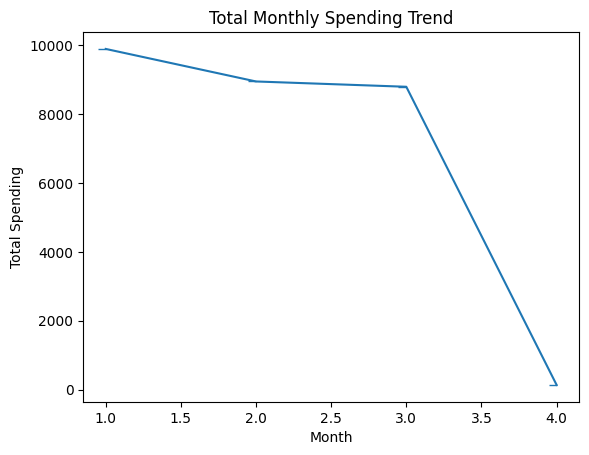

In [ ]:
import matplotlib.pyplot as plt
month_spending.plot(kind='line', marker =0)
plt.title("Total Monthly Spending Trend")
plt.xlabel("Month")
plt.ylabel("Total Spending")
plt.xticks(rotation=0)

plt.show()


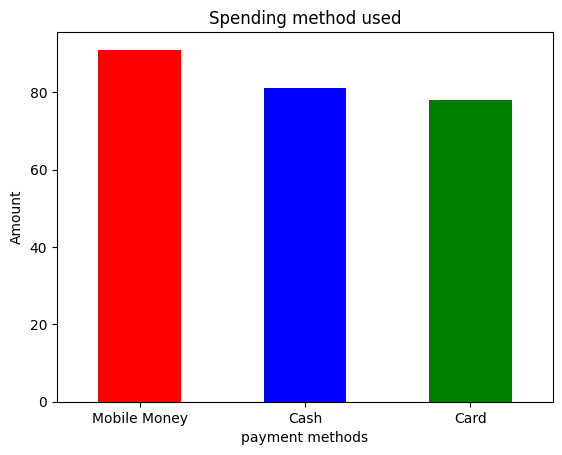

In [63]:
payment_usage.plot(kind='bar', color= ['red', 'blue','green'])

plt.title("Spending method used")
plt.xlabel("payment methods")
plt.ylabel("Amount")
plt.xticks(rotation=0)

plt.show()

### CATEGORY DISTRIBUTION (PIE CHART)    
Shows proportional spending for easy storytelling.

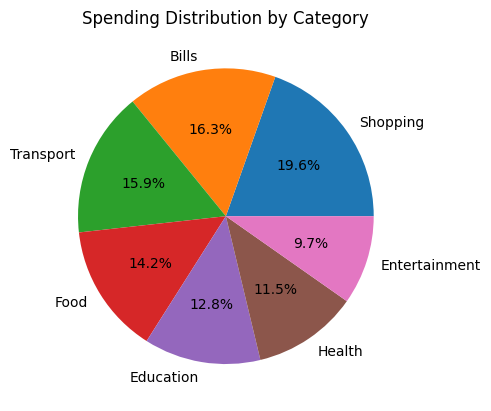

In [62]:
category_spending.plot(kind='pie', autopct='%1.1f%%'
)
plt.title("Spending Distribution by Category")
plt.ylabel("")
plt.show()

### SPENDING BY DAY OF WEEK

<Axes: xlabel='Day_Name'>

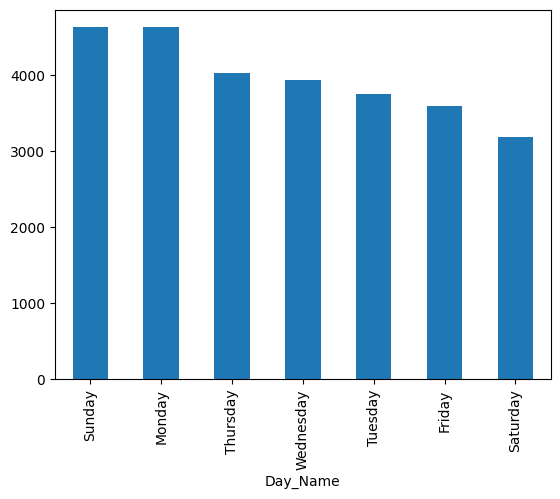

In [ ]:
day_spending.plot(kind= 'bar',)